In [14]:
import pandas as pd     # Imports the pandas library for data manipulation and analysis
import numpy as np      # Imports NumPy for numerical operations (arrays, math functions)
import time             # Imports time utilities (e.g., for measuring durations or sleeps)

Train = pd.read_csv("train-1.csv")  # Loads the CSV file into a pandas DataFrame named 'Train'
Train.info()                        # Prints a concise summary of the DataFrame (columns, dtypes, non-null counts, memory)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29936 entries, 0 to 29935
Data columns (total 73 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   nr..sessions                 29936 non-null  int64  
 1   total.km                     29936 non-null  float64
 2   km.Z3.4                      29936 non-null  float64
 3   km.Z5.T1.T2                  29936 non-null  float64
 4   km.sprinting                 29936 non-null  float64
 5   strength.training            29936 non-null  int64  
 6   hours.alternative            29936 non-null  float64
 7   perceived.exertion           29936 non-null  float64
 8   perceived.trainingSuccess    29936 non-null  float64
 9   perceived.recovery           29936 non-null  float64
 10  nr..sessions.1               29936 non-null  int64  
 11  total.km.1                   29936 non-null  float64
 12  km.Z3.4.1                    29936 non-null  float64
 13  km.Z5.T1.T2.1   

In [15]:
Train.head(10) # gets the 10 entries from the top

,nr..sessions,total.km,km.Z3.4,km.Z5.T1.T2,km.sprinting,strength.training,hours.alternative,perceived.exertion,perceived.trainingSuccess,perceived.recovery,...,km.Z5.T1.T2.6,km.sprinting.6,strength.training.6,hours.alternative.6,perceived.exertion.6,perceived.trainingSuccess.6,perceived.recovery.6,Athlete.ID,injury,Date
0,1,5.8,0.0,0.6,1.2,0,0.00,0.11,0.00,0.18,...,0.0,0.0,0,1.0,0.10,0.00,0.15,0,0,0
1,0,0.0,0.0,0.0,0.0,0,0.00,-0.01,-0.01,-0.01,...,0.5,1.2,0,0.0,0.10,0.00,0.17,0,0,1
2,1,0.0,0.0,0.0,0.0,1,0.00,0.10,0.00,0.17,...,0.0,0.0,0,0.0,-0.01,-0.01,-0.01,0,0,2
3,0,0.0,0.0,0.0,0.0,0,0.00,-0.01,-0.01,-0.01,...,0.0,0.0,1,0.0,0.10,0.00,0.17,0,0,3
4,1,0.0,0.0,0.0,0.0,0,1.08,0.08,0.00,0.18,...,0.0,0.0,0,0.0,0.11,0.00,0.17,0,0,4
5,1,16.4,10.0,0.0,0.0,1,0.00,0.11,0.00,0.17,...,0.0,0.0,0,1.0,0.08,0.00,0.17,0,0,5
6,1,0.0,0.0,0.0,0.0,0,1.00,0.10,0.00,0.15,...,0.0,0.0,0,0.0,0.09,0.00,0.18,0,0,6
7,1,5.2,0.0,0.5,1.2,0,0.00,0.10,0.00,0.17,...,0.0,0.0,0,0.0,-0.01,-0.01,-0.01,0,0,7
8,0,0.0,0.0,0.0,0.0,0,0.00,-0.01,-0.01,-0.01,...,0.0,1.2,0,0.0,0.11,0.00,0.18,0,0,8
9,1,0.0,0.0,0.0,0.0,1,0.00,0.10,0.00,0.17,...,0.0,0.0,0,0.0,-0.01,-0.01,-0.01,0,0,9


In [16]:
Train.describe() # gives us statistics about every entry

,nr..sessions,total.km,km.Z3.4,km.Z5.T1.T2,km.sprinting,strength.training,hours.alternative,perceived.exertion,perceived.trainingSuccess,perceived.recovery,...,km.Z5.T1.T2.6,km.sprinting.6,strength.training.6,hours.alternative.6,perceived.exertion.6,perceived.trainingSuccess.6,perceived.recovery.6,Athlete.ID,injury,Date
count,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,...,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.000000,29936.0,29936.000000
mean,0.816609,7.082673,0.679252,0.598320,0.081992,0.108064,0.159137,0.213451,0.281967,0.171972,...,0.600578,0.081293,0.106928,0.156409,0.212349,0.281489,0.171525,24.950361,0.0,962.567511
std,0.587071,7.538362,2.272321,1.859718,0.536689,0.316856,0.562768,0.242541,0.359192,0.173033,...,1.863452,0.534472,0.315552,0.558244,0.241704,0.359244,0.172831,13.172533,0.0,770.156145
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,...,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,0.000000,0.0,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,...,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,17.000000,0.0,223.000000
50%,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.140000,0.000000,0.150000,...,0.000000,0.000000,0.000000,0.000000,0.140000,0.000000,0.150000,25.000000,0.0,844.000000
75%,1.000000,12.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.340000,0.680000,0.260000,...,0.000000,0.000000,0.000000,0.000000,0.330000,0.680000,0.260000,37.000000,0.0,1507.000000
max,2.000000,55.000000,42.200000,30.000000,40.000000,2.000000,10.000000,1.000000,1.000000,1.000000,...,30.000000,40.000000,2.000000,10.000000,1.000000,1.000000,1.000000,47.000000,0.0,2652.000000


## DATA CLEANING

In [17]:
import numba                              # Imports Numba to speed up Python/numpy code with JIT compilation

# Clear invalid data: Exclude rows where there was no sports training for 7 consecutive days
@numba.njit(parallel=True)                # JIT-compile the function with Numba (nopython mode), enabling parallel loops where possible
def judge_sum(a, b, c, d, e, f, g):      # Define a fast, compiled function that sums seven same-length arrays elementwise
    return a + b + c + d + e + f + g     # Return the elementwise sum across the seven inputs

def DataClear(data):                                                          # Define a function that filters a pandas DataFrame
    columns_original = data.columns                                           # Keep original column names to rebuild a DataFrame later
    data_original = data.values                                               # Convert DataFrame to a NumPy array for fast numeric ops

    # Compute a 7-day activity sum using columns 0,10,20,30,40,50,60 (assumes these are the 7 daily columns)
    judge = judge_sum(data_original[:, 0],                                    # Day 1 values
                      data_original[:, 10],                                   # Day 2 values
                      data_original[:, 20],                                   # Day 3 values
                      data_original[:, 30],                                   # Day 4 values
                      data_original[:, 40],                                   # Day 5 values
                      data_original[:, 50],                                   # Day 6 values
                      data_original[:, 60])                                   # Day 7 values

    index = np.where(judge != 0)                                              # Find row indices where the 7-day sum is not zero (i.e., had some training)
    data_new = data_original[index]                                           # Select only those rows from the NumPy array
    return pd.DataFrame(data_new, columns=columns_original)                   # Rebuild and return a DataFrame with the filtered rows

In [18]:
import time                                                # Imports the time module to measure elapsed time

start = time.time()                                        # Record the current time (seconds since epoch) as the start timestamp
Train_Clear = DataClear(Train)                             # Run the DataClear() function on the Train DataFrame to filter rows
end = time.time()                                          # Record the current time again as the end timestamp

print("Train samples:",                                    # Print a summary line:
      Train_Clear.shape[0],                                #   number of rows (samples) in the cleaned DataFrame
      "time:", end - start)                                #   and the elapsed time (seconds) for DataClear()

Train samples: 28047 time: 0.5269386768341064


In [19]:
Train_Clear.describe()

,nr..sessions,total.km,km.Z3.4,km.Z5.T1.T2,km.sprinting,strength.training,hours.alternative,perceived.exertion,perceived.trainingSuccess,perceived.recovery,...,km.Z5.T1.T2.6,km.sprinting.6,strength.training.6,hours.alternative.6,perceived.exertion.6,perceived.trainingSuccess.6,perceived.recovery.6,Athlete.ID,injury,Date
count,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,...,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.000000,28047.0,28047.000000
mean,0.871608,7.559700,0.725001,0.638617,0.087514,0.115342,0.169855,0.228500,0.301631,0.184228,...,0.641028,0.086769,0.114130,0.166944,0.227325,0.301121,0.183751,24.821763,0.0,973.423432
std,0.565621,7.553018,2.340524,1.914618,0.554032,0.326068,0.579844,0.243308,0.362740,0.171978,...,1.918438,0.551748,0.324743,0.575211,0.242490,0.362823,0.171795,12.992005,0.0,781.302114
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,...,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,0.000000,0.0,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.0,224.500000
50%,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.140000,0.000000,0.160000,...,0.000000,0.000000,0.000000,0.000000,0.140000,0.000000,0.160000,24.000000,0.0,851.000000
75%,1.000000,12.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.360000,0.700000,0.270000,...,0.000000,0.000000,0.000000,0.000000,0.360000,0.700000,0.270000,37.000000,0.0,1552.000000
max,2.000000,55.000000,42.200000,30.000000,40.000000,2.000000,10.000000,1.000000,1.000000,1.000000,...,30.000000,40.000000,2.000000,10.000000,1.000000,1.000000,1.000000,47.000000,0.0,2652.000000


In [20]:
def Padding(data):                                          # Rearranges a 70-length 1D array into 8 rows (7 days + 1 padded row)
    day_7 = data[0:10]                                      # Take elements 0–9  (10 values)
    day_6 = data[10:20]                                     # Take elements 10–19
    day_5 = data[20:30]                                     # Take elements 20–29
    day_4 = data[30:40]                                     # Take elements 30–39
    day_3 = data[40:50]                                     # Take elements 40–49
    day_2 = data[50:60]                                     # Take elements 50–59
    day_1 = data[60:70]                                     # Take elements 60–69
    day_8 = np.zeros(10, dtype=float)  # padding            # Create a zero row (10 floats) to pad to 8 rows total
    data_reshape = np.vstack((day_1, day_2, day_3, day_4,   # Stack rows in reverse chronological order + padding:
                              day_5, day_6, day_7, day_8))  #   day_1 (most recent) → day_7 (oldest) → day_8 (zeros)
    return data_reshape                                     # Return the resulting (8, 10) array

@numba.njit()                                               # JIT-compile to a fast machine-code function with Numba
def TransformInt(data):                                     # Convert a single value to Python int (for labels/IDs)
    return int(data)                                        # Cast and return as int

def List_to_arr(data_list, data):                           # Convert a list of feature arrays + info into aligned arrays
    new_data = []                                           # Will collect filtered feature arrays
    data_information = []                                   # Will collect the corresponding metadata rows

    for i in range(len(data_list)):                         # Iterate over all samples
        temp_feature = data_list[i]                         # Feature array for sample i (e.g., (8, 10) after Padding)
        temp_information = data[i]                          # Metadata/info for sample i (ID, label, date, etc.)
        if np.sum(temp_feature[:, 0]) != 0:                 # Keep sample only if the first column has nonzero total
            new_data.append(temp_feature)                   #   (filters out all-zero/empty sequences)
            data_information.append(temp_information)       # Keep its metadata in sync

    new_data = np.array(new_data)                           # Convert feature list → NumPy array (N, 8, 10)
    data_information = np.array(data_information)           # Convert metadata list → NumPy array (N, ?)
    ID = data_information[:, 0]                             # First column is assumed to be an ID
    Label = np.array(list(map(TransformInt,                 # Second column is label → cast each to int via Numba fn
                              data_information[:, 1])))
    Date = data_information[:, 2]                           # Third column is assumed to be a date/string

    return new_data, ID, Label, Date                        # Return aligned arrays: features, IDs, labels, dates

In [21]:
import time  # Import the time module to measure how long the operations take

start = time.time()  # Capture the start timestamp (in seconds since epoch)

Train_reshape = list(map(Padding, Train_Clear.values))  # Apply Padding() to each row of Train_Clear (as a NumPy array), producing a list of (8, 10) arrays
Train_Feature, Train_ID, Train_Label, Train_Date = List_to_arr(Train_reshape, Train_Clear.values)  # Convert features+metadata into aligned arrays: features, IDs, labels, dates

end = time.time()  # Capture the end timestamp

print("time:", end - start,                                  # Print elapsed time for the above processing
      f"\nOriginal TrainSet: {np.array(Train_reshape).shape}")  # Convert list to NumPy array to show its shape (e.g., (N, 8, 10))

time: 0.4745175838470459 
Original TrainSet: (28047, 8, 10)


## GRAMIAN ANGULAR FIELD

In [22]:
n_sample = 27999 # define the number of samples

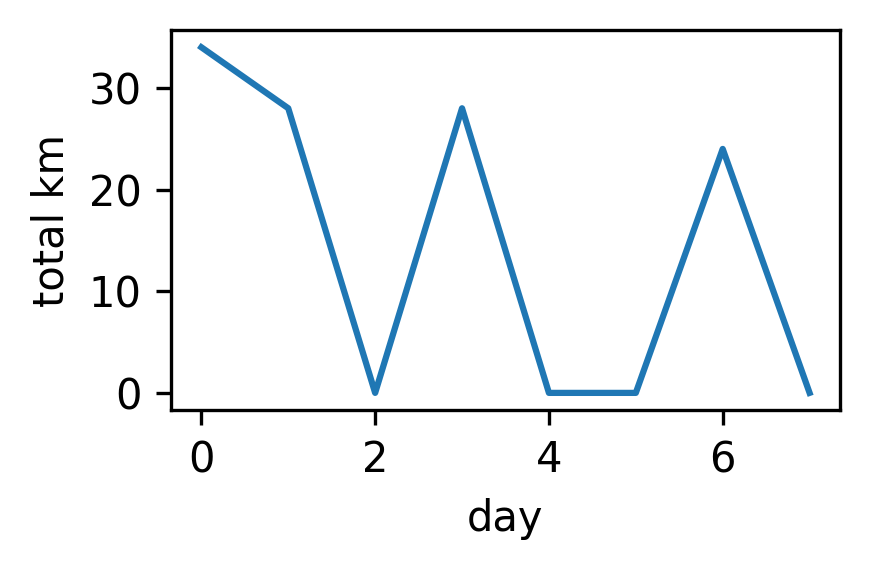

In [23]:
import matplotlib.pyplot as plt                      # Imports Matplotlib's plotting API

X_new = Train_Feature[n_sample, :, 1]               # Pick one sample (n_sample), all 8 rows, column 1 feature (e.g., "total km")
X_sample = [list(range(0, 8, 1)), X_new]            # Build x-values [0..7] for days and y-values from the selected feature

fig = plt.figure(figsize=(3, 2), dpi=300, edgecolor='black')  # Create a small, high-DPI figure with a black edge
plt.plot(X_sample[0], X_sample[1])                  # Plot day index (x) vs. total km (y)

plt.xlabel("day")                                   # Label the x-axis
plt.ylabel("total km")                              # Label the y-axis
plt.tight_layout()                                  # Adjust layout to prevent label clipping
plt.show()                                          # Render the plot to the screen

In [24]:
pip install pyts # install the pyts module

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.5 MB/s eta 0:00:00


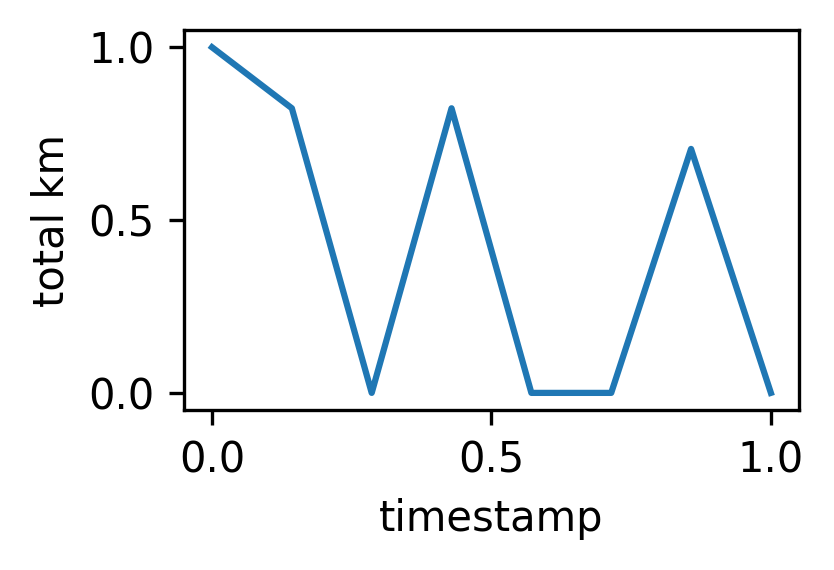

In [25]:
from pyts.preprocessing import MinMaxScaler        # Imports a time-series Min-Max scaler (scales each series to [0, 1])

# normalization
scaler = MinMaxScaler()                            # Create the scaler (it will learn min/max when you fit it)
X_sample_scaler = scaler.transform(X_sample)       # Transform X_sample using the learned min/max (requires the scaler to be FIT beforehand)

fig = plt.figure(figsize=(3, 2), dpi=300, edgecolor='black')  # Create a compact, high-DPI figure with a black border
plt.plot(X_sample_scaler[0, :], X_sample_scaler[1, :])        # Plot normalized timestamps (row 0) vs normalized values (row 1)

plt.xlabel("timestamp")                            # Label x-axis
plt.ylabel("total km")                             # Label y-axis
plt.tight_layout()                                 # Prevent label/axis clipping
plt.show()                                         # Display the plot

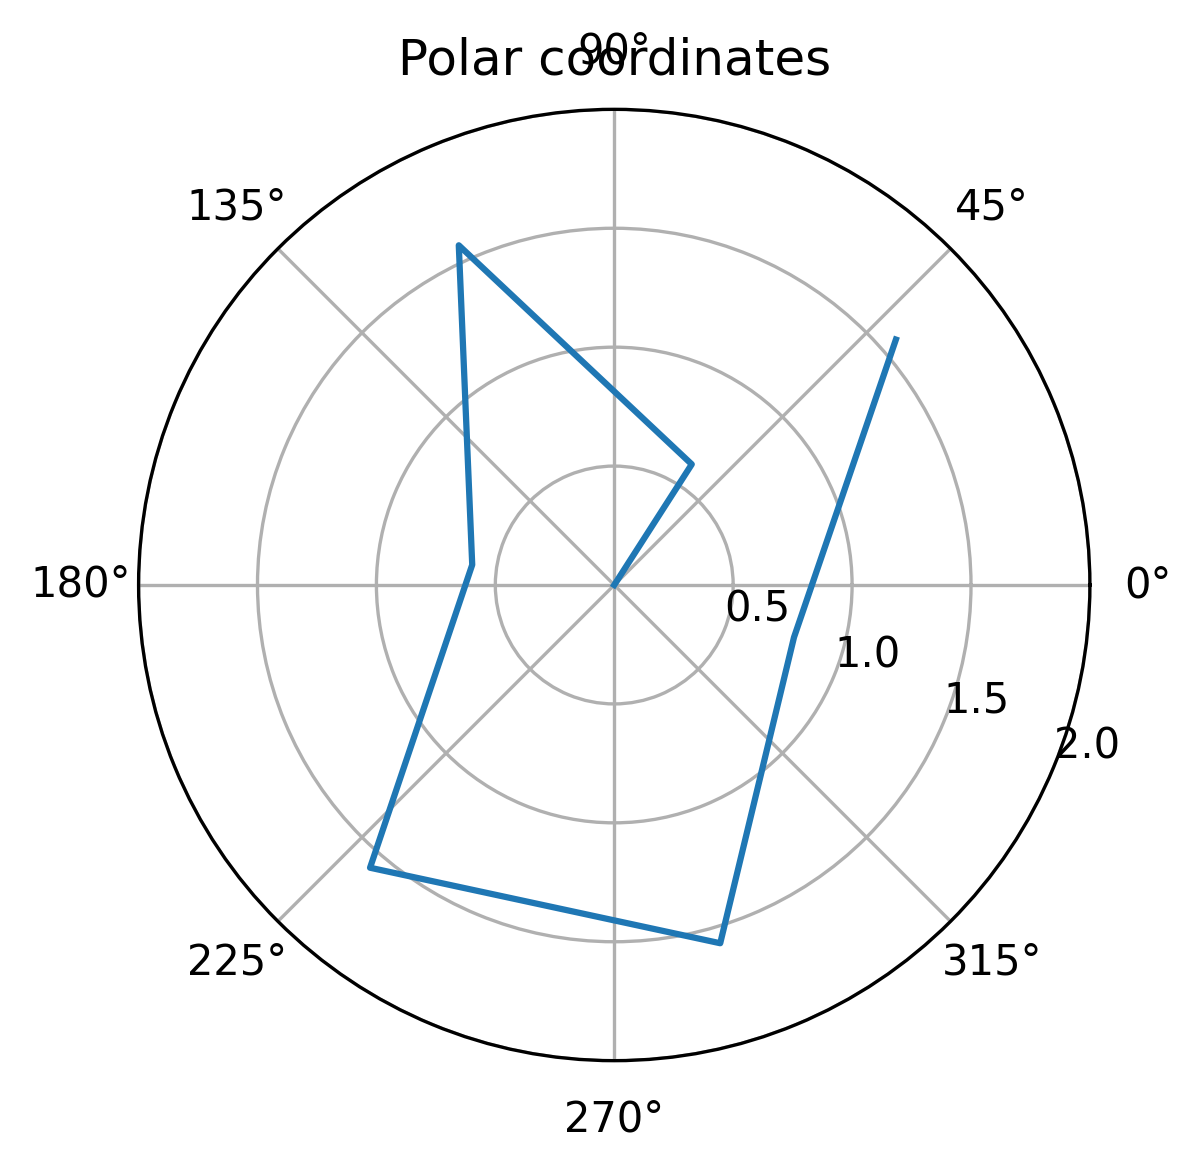

In [26]:
arccos_X = np.arccos(X_sample_scaler[1, :])                           # Take arccos of the normalized series (range [0,1]) → values in [0, π]

fig, ax = plt.subplots(figsize=(6, 4), dpi=300,                       # Create a figure and a single polar subplot
                       subplot_kw={'projection': 'polar'})

ax.plot(X_sample[0], arccos_X)                                        # Plot polar curve: theta = timestamps, r = arccos(series)
ax.set_rmax(2)                                                        # Set the maximum radial limit to 2 (tightens the radial extent)
ax.set_rticks([0.5, 1, 1.5, 2])                                       # Choose fewer, specific radial tick marks
ax.set_rlabel_position(-22.5)                                         # Rotate radial labels to avoid overlapping the plotted line
ax.grid(True)                                                         # Show polar grid for readability
ax.set_title("Polar coordinates", va='bottom')                        # Add a title; align vertically to bottom of the title area
plt.tight_layout()                                                    # Adjust layout to prevent clipping at high DPI
plt.show()                                                            # Render the polar plot

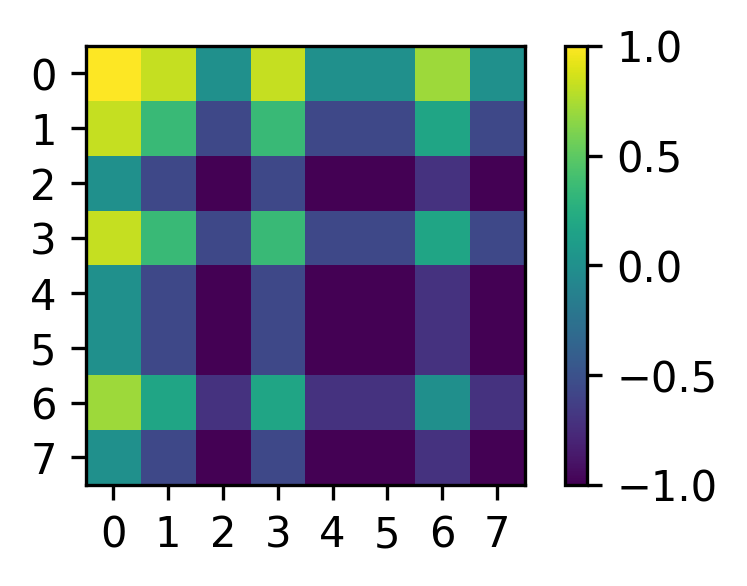

In [27]:
from matplotlib.pyplot import MultipleLocator                      # (Note) MultipleLocator normally lives in matplotlib.ticker; this import may fail in some setups

fig = plt.figure(figsize=(3, 2), dpi=300, edgecolor='black')       # Create a small high-DPI figure with a black edge
field = [a + b for a in arccos_X for b in arccos_X]                # Build all pairwise sums of arccos_X values (length 8×8 = 64)
gram = np.cos(field).reshape(8, 8)                                 # Take cosine of each sum and reshape into an 8×8 matrix (a cosine-sum “Gram” matrix)

plt.imshow(pd.DataFrame(gram).rename(                              # Show the matrix as a heatmap; wrap in DataFrame to rename axes to 1..8
    index={0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8},
    columns={0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8}
))

ax = plt.gca()                                                     # Get the current Axes to customize ticks
major_locator = MultipleLocator(1)                                 # Create a locator that places major ticks every 1 unit
ax.xaxis.set_major_locator(major_locator)                          # Apply the 1-unit tick spacing on the x-axis
ax.yaxis.set_major_locator(major_locator)                          # Apply the 1-unit tick spacing on the y-axis
plt.tight_layout()                                                 # Reduce padding/clipping around the plot
plt.colorbar()                                                     # Add a colorbar to interpret the heatmap scale

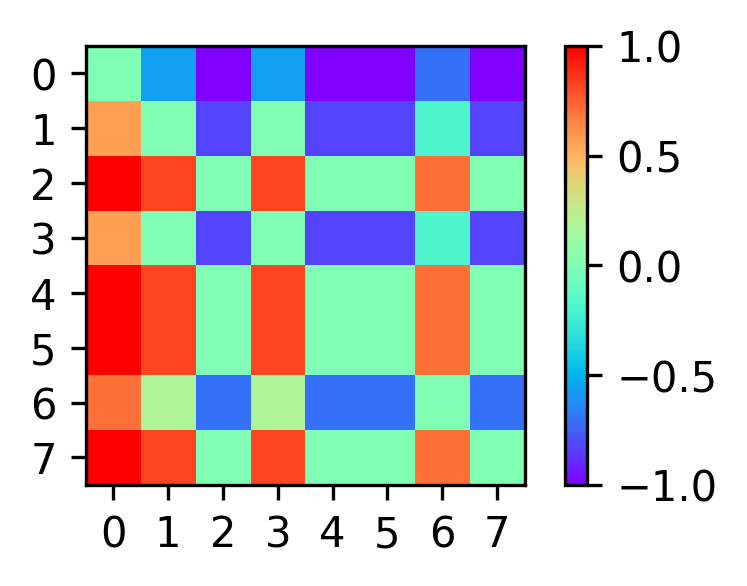

In [28]:
fig = plt.figure(figsize=(3, 2), dpi=300, edgecolor='black')  # Create a compact, high-DPI figure with a black border
field = [a - b for a in arccos_X for b in arccos_X]          # Compute all pairwise differences of arccos_X (length 8×8 = 64)
gram = np.sin(field).reshape(8, 8)                            # Apply sine to each difference and reshape into an 8×8 matrix

plt.imshow(pd.DataFrame(gram).rename(                         # Display as a heatmap; wrap in DataFrame to relabel axes 1..8
    index={0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8},
    columns={0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8}
))
ax = plt.gca()                                                # Get current Axes to customize ticks
major_locator = MultipleLocator(1)                            # Set major tick spacing to every 1 unit
ax.xaxis.set_major_locator(major_locator)                     # Apply locator to x-axis
ax.yaxis.set_major_locator(major_locator)                     # Apply locator to y-axis

plt.imshow(gram, cmap='rainbow')                              # (Optional) Re-draw the heatmap directly with a 'rainbow' colormap
plt.tight_layout()                                            # Adjust layout to minimize clipping at high DPI
plt.colorbar()                                                # Add a colorbar to show the heatmap's scale

## MARKOV TRANSITION FIELD TRANSFORMATION

In [29]:
X_new = X_sample_scaler[1, :]   # Extract the normalized value series (row 1) across all timestamps (all columns)

In [30]:
from pyts.preprocessing.discretizer import KBinsDiscretizer   # Import time-series KBinsDiscretizer (bins continuous data into symbols)

n_bins = 5                                                    # Number of discrete bins (symbols) to use
strategy = 'quantile'                                         # Binning rule: equal-frequency bins based on quantiles
discretizer = KBinsDiscretizer(                               # Create the discretizer with chosen params
    n_bins=n_bins, strategy=strategy, raise_warning=False
)

X = X_new.reshape(1, -1)                                      # Reshape 1D series → shape (1, T) as expected by fit/transform
X_disc = discretizer.fit_transform(X)[0]                      # Fit on this series and transform → get discretized 1D array
X_disc                                                        # Show the discretized sequence (e.g., integers 0..n_bins-1)

array([3, 2, 0, 2, 0, 0, 1, 0])

In [31]:
m_adj = np.zeros((n_bins, n_bins))        # Initialize an n_bins×n_bins transition matrix filled with zeros

for k in range(len(X_disc) - 1):          # Loop over each adjacent pair in the discretized sequence
    # matrix iteration
    index = X_disc[k]                     # Current symbol/bin index at position k
    next_index = X_disc[k + 1]            # Next symbol/bin index at position k+1
    m_adj[next_index][index] += 1         # Increment transition count from 'index' → 'next_index'

print(m_adj)                              # Display the transition matrix (row=to, column=from)

[[1. 1. 2. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [32]:
mtm = m_adj / m_adj.sum(axis=0)   # Convert raw transition counts to a column-normalized transition matrix:
                                  #   divide each column by its column sum so each column sums to 1 (probabilities)
print(mtm)                        # Print the Markov transition matrix (P[next_bin | current_bin])

[[0.33333333 1.         1.         0.                nan]
 [0.33333333 0.         0.         0.                nan]
 [0.33333333 0.         0.         1.                nan]
 [0.         0.         0.         0.                nan]
 [0.         0.         0.         0.                nan]]


/tmp/ipython-input-2458778215.py:1: RuntimeWarning: invalid value encountered in divide
  mtm = m_adj / m_adj.sum(axis=0)   # Convert raw transition counts to a column-normalized transition matrix:


In [33]:
n_t = len(X_disc)                                   # Number of time steps (length of the discretized series)
mtf = np.zeros((n_t, n_t))                          # Initialize an n_t × n_t Markov Transition Field (MTF) matrix

for i in range(n_t):                                # Loop over each time index i
    for j in range(n_t):                            # Loop over each time index j
        mtf[i, j] = mtm[X_disc[i]][X_disc[j]] * 100 # Set MTF entry using transition prob. from bin at i → bin at j (scaled ×100)

In [34]:
mtf # Display the Markov Transition Field matrix computed above

array([[  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ],
       [100.        ,   0.        ,  33.33333333,   0.        ,
         33.33333333,  33.33333333,   0.        ,  33.33333333],
       [  0.        , 100.        ,  33.33333333, 100.        ,
         33.33333333,  33.33333333, 100.        ,  33.33333333],
       [100.        ,   0.        ,  33.33333333,   0.        ,
         33.33333333,  33.33333333,   0.        ,  33.33333333],
       [  0.        , 100.        ,  33.33333333, 100.        ,
         33.33333333,  33.33333333, 100.        ,  33.33333333],
       [  0.        , 100.        ,  33.33333333, 100.        ,
         33.33333333,  33.33333333, 100.        ,  33.33333333],
       [  0.        ,   0.        ,  33.33333333,   0.        ,
         33.33333333,  33.33333333,   0.        ,  33.33333333],
       [  0.        , 100.        ,  33.33333333, 100.        ,
         33.33333333,  33.3333333

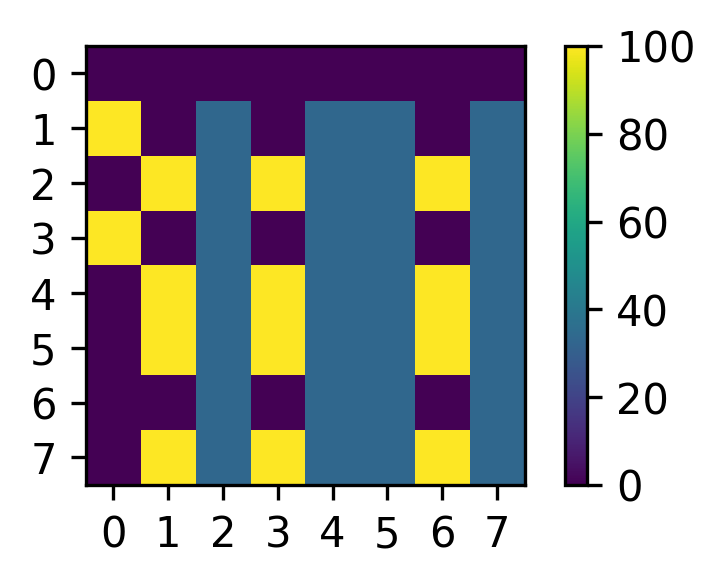

In [35]:
fig = plt.figure(figsize=(3, 2), dpi=300, edgecolor='black')   # Create a compact, high-DPI figure with a black border
plt.imshow(pd.DataFrame(mtf).rename(                           # Show the MTF as a heatmap, wrapping in a DataFrame to relabel axes
    index={0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8},            # Rename row indices 0..7 → 1..8 for display
    columns={0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8}           # Rename column indices 0..7 → 1..8 for display
))
ax = plt.gca()                                                 # Get the current Axes to customize ticks
major_locator = MultipleLocator(1)                             # Set major tick spacing to every 1 unit
ax.xaxis.set_major_locator(major_locator)                      # Apply locator to x-axis (tick every 1)
ax.yaxis.set_major_locator(major_locator)                      # Apply locator to y-axis (tick every 1)
plt.tight_layout()                                             # Reduce padding/clipping around the plot
plt.colorbar()                                                 # Add a colorbar to interpret the heatmap scale
plt.show()                                                     # Render the figure

## RECCURENCE PLOT TRANSFORMATION

In [36]:
from scipy.spatial.distance import pdist, squareform   # Pairwise distances (pdist) and convert condensed vector ↔ square matrix (squareform)

eps = 0.10                                             # Distance bin width (epsilon) used to quantize distances
steps = 10                                             # Maximum bin index; distances beyond this cap will be clipped

d = pdist(X_new[:, None])                              # Compute all pairwise Euclidean distances between points in X_new (shape: (n*(n-1)/2,))
d = np.floor(d / eps)                                  # Quantize distances: divide by eps and take floor to get discrete bins
d[d > steps] = steps                                   # Clip large bins to the maximum allowed bin index

Z = squareform(d)                                      # Convert the condensed distance-bins vector into an (n×n) symmetric matrix
d                                                      # Show the condensed, quantized, clipped distance array

array([ 1., 10.,  1., 10., 10.,  2., 10.,  8.,  0.,  8.,  8.,  1.,  8.,
        8.,  0.,  0.,  7.,  0.,  8.,  8.,  1.,  8.,  0.,  7.,  0.,  7.,
        0.,  7.])

In [37]:
Z # display the symmetric matrix

array([[ 0.,  1., 10.,  1., 10., 10.,  2., 10.],
       [ 1.,  0.,  8.,  0.,  8.,  8.,  1.,  8.],
       [10.,  8.,  0.,  8.,  0.,  0.,  7.,  0.],
       [ 1.,  0.,  8.,  0.,  8.,  8.,  1.,  8.],
       [10.,  8.,  0.,  8.,  0.,  0.,  7.,  0.],
       [10.,  8.,  0.,  8.,  0.,  0.,  7.,  0.],
       [ 2.,  1.,  7.,  1.,  7.,  7.,  0.,  7.],
       [10.,  8.,  0.,  8.,  0.,  0.,  7.,  0.]])

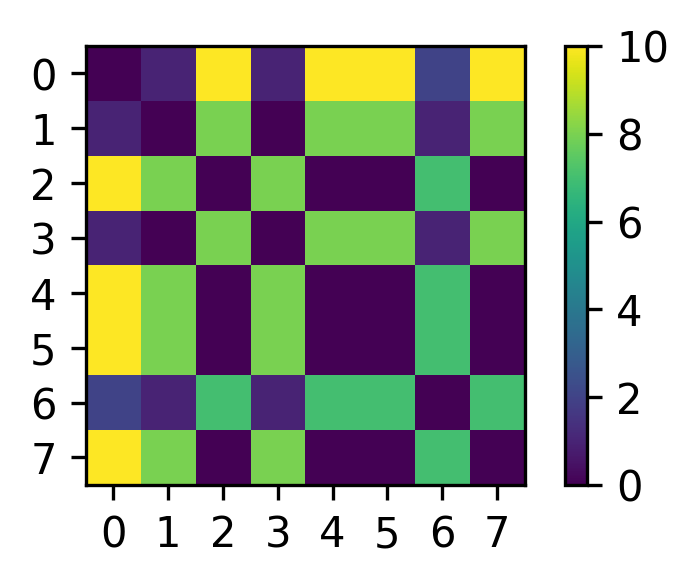

In [38]:
fig = plt.figure(figsize=(3, 2), dpi=300, edgecolor='black')   # Create a compact, high-DPI figure with a black border
plt.imshow(pd.DataFrame(Z).rename(                             # Visualize the quantized distance matrix Z as a heatmap
    index={0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8},            # Relabel row indices 0..7 → 1..8 for readability
    columns={0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8}           # Relabel column indices 0..7 → 1..8
))
ax = plt.gca()                                                 # Get the current Axes object for further customization
major_locator = MultipleLocator(1)                             # Place major ticks at every integer position
ax.xaxis.set_major_locator(major_locator)                      # Apply the locator to the x-axis
ax.yaxis.set_major_locator(major_locator)                      # Apply the locator to the y-axis
plt.tight_layout()                                             # Reduce padding/clipping around the plot
plt.colorbar()                                                 # Add a colorbar to interpret the heatmap values
plt.show()                                                     # Render the heatmap

## NOVELTY SECTION -- CNN

In [39]:
from sklearn.preprocessing import MinMaxScaler  # Imports scikit-learn's MinMaxScaler to scale features to a given range (default [0, 1])
import numpy as np                              # Imports NumPy for numerical arrays and vectorized math operations

In [40]:
def generate_gaf_channels(sample, feature_indices):                     # Create GAF (Gramian Angular Field) image channels for selected features
    scaler = MinMaxScaler(feature_range=(0.1, 0.9))                    # Min–max scaler mapping each series to [0.1, 0.9] (avoid 0/1 for arccos stability)
    channels = []                                                      # Will collect one 8×8 GAF matrix per feature index

    for idx in feature_indices:                                        # Loop over each feature column to convert into a GAF channel
        series = sample[:, idx]                                        # Extract the 1D time series for this feature (length 8 expected)
        scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten() # Scale series to [0.1, 0.9]; keep as 1D array
        arccos = np.arccos(scaled)                                     # Map scaled values to angular values θ = arccos(x) ∈ (0, π)
        field = [a + b for a in arccos for b in arccos]                # Build all pairwise angle sums θ_i + θ_j (length 8×8 = 64)
        gram = np.cos(field).reshape(8, 8)                             # GAF (summation form): G_ij = cos(θ_i + θ_j) → 8×8 image
        channels.append(gram)                                          # Store this feature’s GAF image

    return np.moveaxis(np.stack(channels), 0, -1)  # shape: (8, 8, 3)   # Stack to (num_features, 8, 8) then move axis → (8, 8, num_features)

In [41]:
# Apply to all samples
feature_indices = [1, 4, 6]                                              # Choose which feature columns to convert into GAF channels (3 channels)
gaf_images = np.array([generate_gaf_channels(sample, feature_indices)     # For each sample (8×F), make an (8×8×3) GAF image
                       for sample in Train_Feature])

from sklearn.model_selection import train_test_split                       # Utility to split arrays into train/test subsets

X_train, X_test, y_train, y_test = train_test_split(                       # Split GAF images and labels into train/test sets
    gaf_images, Train_Label, test_size=0.2, random_state=42)               # 80% train / 20% test, deterministic split with seed 42

# Ensure correct format
X_train = X_train.astype('float32')                                        # Cast training images to float32 (common for DL frameworks)
X_test  = X_test.astype('float32')                                         # Cast test images to float32

num_classes = int(np.max(y_train)) + 1                                     # Compute number of classes assuming labels are 0..K-1
print("Number of classes:", num_classes)  # Should be 56                    # Display class count (comment reflects expected value)

import tensorflow as tf                                                    # Import TensorFlow for building input pipelines / models

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))          # Wrap training arrays into a tf.data Dataset
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))            # Wrap test arrays into a tf.data Dataset

train_ds = train_ds.shuffle(1000).batch(64).prefetch(tf.data.AUTOTUNE)     # Shuffle, batch to 64 samples, overlap CPU/GPU via prefetch
test_ds  = test_ds.batch(64).prefetch(tf.data.AUTOTUNE)                    # Batch test set and prefetch for efficient evaluation

Number of classes: 56


In [43]:
from tensorflow.keras import layers, models                           # Import Keras layers and model-building API

num_classes = int(np.max(y_train)) + 1  # Ensure all label values are covered  # Compute number of classes assuming labels are 0..K-1

model = models.Sequential([                                             # Build a simple convolutional classifier
    layers.Input(shape=(8, 8, 3)),                                     # Input: 8×8 GAF image with 3 channels
    layers.Conv2D(32, (3, 3), activation='relu'),                      # Conv layer: 32 filters, 3×3 kernel, ReLU nonlinearity
    layers.MaxPooling2D((2, 2)),                                       # Downsample feature maps by 2×2 pooling
    layers.Conv2D(64, (3, 3), activation='relu'),                      # Second conv layer: 64 filters, 3×3 kernel
    layers.Flatten(),                                                  # Flatten spatial maps to a 1D vector
    layers.Dense(64, activation='relu'),                               # Fully connected layer with 64 hidden units
    layers.Dropout(0.3),                                               # Dropout (30%) to reduce overfitting
    layers.Dense(num_classes, activation='softmax')                    # Output layer: class probabilities over num_classes
])

model.compile(optimizer='adam',                                        # Use Adam optimizer (adaptive learning rate)
              loss='sparse_categorical_crossentropy',                  # Loss for integer labels (no one-hot needed)
              metrics=['accuracy'])                                    # Track accuracy during training/eval

history = model.fit(train_ds, epochs=20, validation_data=test_ds)      # Train for 20 epochs, validate on test_ds each epoch

test_loss, test_acc = model.evaluate(test_ds)                          # Evaluate final model performance on test set
print(f"Test Accuracy: {test_acc:.2f}")                                # Print test accuracy with 2 decimal places

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3667 - loss: 2.6494 - val_accuracy: 0.4371 - val_loss: 1.8810
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4284 - loss: 1.9214 - val_accuracy: 0.4451 - val_loss: 1.8224
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4406 - loss: 1.8341 - val_accuracy: 0.4446 - val_loss: 1.7920
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4408 - loss: 1.8072 - val_accuracy: 0.4439 - val_loss: 1.7695
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4445 - loss: 1.7859 - val_accuracy: 0.4485 - val_loss: 1.7904
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4490 - loss: 1.7697 - val_accuracy: 0.4524 - val_loss: 1.7454
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4506 - loss: 1.7471 - val_accuracy: 0.4531 - val_loss: 1.7264
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4482 - loss: 1.7405 - val_accuracy: 0.

**Above Explanation:** Our novelty pipeline uses a 3-channel GASF model with images from a few features + a shallow CNN, where it is learning some signal but plateaus mid-40%. The train and val set curves move together, so not much overfitting but there is limited capacity/signal. The paper uses richer encodings including GASF/GADF/MTF and learns representations with a DCAE before classification. The best generalizing model of the parent paper is (GASF-DCAE-DNN), which delivers strong test AUC/Specificity in a binary setting, highlighting the value of stronger representation and encodings.

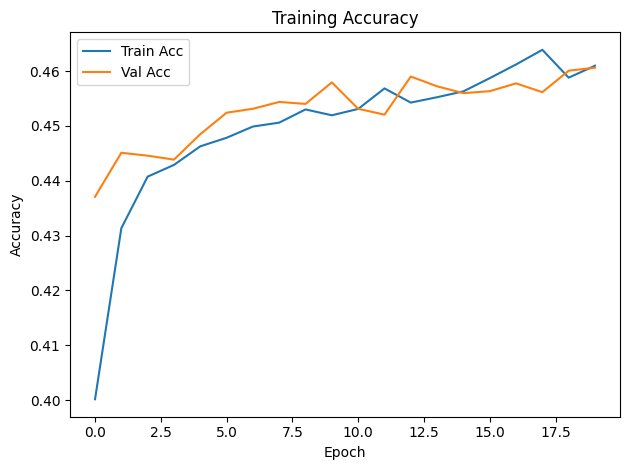

In [44]:
import matplotlib.pyplot as plt                                # Import Matplotlib plotting API

plt.plot(history.history['accuracy'], label='Train Acc')       # Plot training accuracy per epoch
plt.plot(history.history['val_accuracy'], label='Val Acc')     # Plot validation accuracy per epoch
plt.title("Training Accuracy")                                 # Add a title to the chart
plt.xlabel("Epoch")                                            # Label x-axis as epoch index
plt.ylabel("Accuracy")                                         # Label y-axis as accuracy
plt.legend()                                                   # Show the legend for the two curves
plt.tight_layout()                                             # Adjust layout to prevent label clipping
plt.show()                                                     # Render the figure

**Above Explanation:** There is a Stable gap in the graph which suggests our model isn't overfitting. It is more likely that it is underpowered / underspecified for the task or features are too limited. The papers results section interprets similar “parallel curves” as good fit for the representation step, and flags overfitting when curves separate. Our curves don't, so we would've likely need richer inputs/architecture rather than more regularization.

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


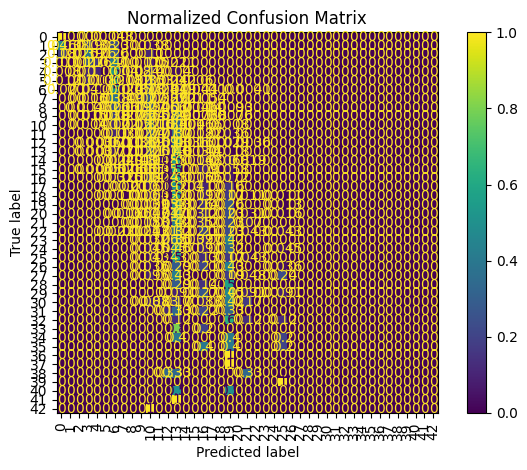

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Tools to compute and plot a confusion matrix
import numpy as np                                                   # NumPy for array operations
import matplotlib.pyplot as plt                                      # Matplotlib for plotting

# Get predictions
y_pred = model.predict(test_ds).argmax(axis=1)                       # Predict class probabilities for test_ds, then take argmax → predicted class IDs

# Extract true labels from test_ds
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)     # Collect true labels from the tf.data Dataset into a single 1D NumPy array

# Compute raw confusion matrix
cm = confusion_matrix(y_true, y_pred)                                # Build confusion matrix: rows = true classes, cols = predicted classes (counts)

# Normalize by row (true label) to show percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)   # Row-normalize so each row sums to 1.0 (class-wise proportions)

# Display normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized)        # Create a display object from the normalized matrix
disp.plot(cmap='viridis', xticks_rotation='vertical')                # Plot with a colormap and vertical x-tick labels
plt.title("Normalized Confusion Matrix")                             # Title for the plot
plt.tight_layout()                                                   # Adjust layout to avoid clipping
plt.show()                                                           # Render the plot

**Above Explanation:** This pattern in the confusion matrix shows a classic class imbalance + limited separability: the model doesn't form sharp boundaries for many classes. The paper explicitly rebalances with SMOTETomek and evaluates with AUC/G-mean/Sensitivity/Specificity because raw accuracy is misleading under imbalance. Our setup doesn't show that rebalancing, which helps explain the broad confusion.

## TOP TEN CLASSES CONFUSION MATRIX

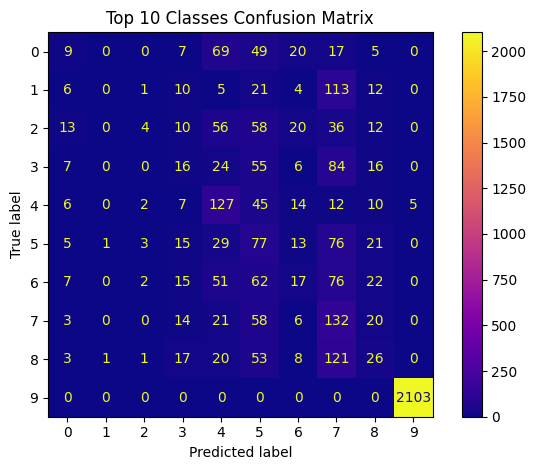

In [46]:
top_classes = np.argsort(np.bincount(y_true))[-10:]        # Find the 10 most frequent true classes: count each label, sort by count, take last 10 (largest)

cm_top = cm[np.ix_(top_classes, top_classes)]              # Extract the confusion-matrix sub-block for those top classes (rows & cols reordered to match)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_top)     # Create a display object for the (counts) confusion matrix of top classes
disp.plot(cmap='plasma')                                   # Plot it with a 'plasma' colormap for visual contrast

plt.title("Top 10 Classes Confusion Matrix")               # Add a descriptive title
plt.tight_layout()                                         # Adjust layout to prevent label/title clipping
plt.show()                                                 # Render the plot

**Above Explanation:** The dominance of one/few classes in our novelty is exactly why the paper balances the training set (Tomek-link removal of majority neighbors + SMOTE for minority samples) before modeling. Without that, our model gravitate to the head classes and suppress recall on others. The parent papers pipeline then feeds balanced, image-encoded sequences (GASF/GADF/MTF) into a DCAE to learn robust features before the classifier.